# **Flower Classification Competition (30%)**
For this competition, we will use the Flower Recognition. This dataset contains 4317 images of flowers. The data collection is based on the data from flickr, google images, yandex images. The aim is to recognize flower species from a photo.  

The pictures are divided into five classes: chamomile, tulip, rose, sunflower, dandelion. For each class there are about 800 photos. Photos are not high resolution, about 320x240 pixels. Note that for this dataset the photos are not all at a fixed size, they have different proportions.

We provide baseline code that includes the following features:

*   Loading and Analysing the Flowers dataset using torchvision.
*   Providing some augmentations (on loading)
*   Defining a simple convolutional neural network.
*   How to use existing loss function for the model learning.
*   Train the network on the training data.
*   Test the trained network on the testing data.
*   Generate prediction for the random test image(s).

The following improvements could be considered:
-------
1. Change of advanced training parameters: Learning Rate, Optimizer, Batch-size, Number of Max Epochs, and Drop-out.
2. Use of a new loss function.
3. Additional/better data augmentation
4. Architectural Changes: Batch Normalization, Residual layers, Attention Block, and other variants.

Your code should be modified from the provided baseline. A pdf report of a maximum of two pages is required to explain the changes you made from the baseline, why you chose those changes, and the improvements they achieved.

Marking Rules:
-------
We will mark the competition based on the final test accuracy on testing images and your report.

Final mark (out of 50) = acc_mark + efficiency mark + report mark
###Acc_mark 10:

We will rank all the submission results based on their test accuracy. Zero improvement over the baseline yields 0 marks. Maximum improvement over the baseline will yield 10 marks. There will be a sliding scale applied in between.

###Efficiency mark 10:

Efficiency considers not only the accuracy, but the computational cost of running the model (flops: https://en.wikipedia.org/wiki/FLOPS). Efficiency for our purposes is defined to be the ratio of accuracy (in %) to Gflops. Please report the computational cost for your final model and include the efficiency calculation in your report. Maximum improvement over the baseline will yield 10 marks. Zero improvement over the baseline yields zero marks, with a sliding scale in between.

###Report mark 30:
Your report should comprise:
1. An introduction showing your understanding of the task and of the baseline model: [10 marks]

2. A description of how you have modified aspects of the system to improve performance. [10 marks]

A recommended way to present a summary of this is via an "ablation study" table, eg:

|Method1|Method2|Method3|Accuracy|
|---|---|---|---|
|N|N|N|60%|
|Y|N|N|65%|
|Y|Y|N|77%|
|Y|Y|Y|82%|

3. Explanation of the methods for reducing the computational cost and/or improve the trade-off between accuracy and cost: [5 marks]

4. Limitations/Conclusions: [5 marks]

In [ ]:
##################################################################################################################################
### Subject: Computer Vision
### Year: 2025
### Student Name: Liam Blaschka
### Student ID: a1888420
### Comptetion Name: Flowers Classification Competition
### Final Results:
### ACC: 92.593%        GFLOPs: 0.42060
##################################################################################################################################

In [2]:
# Importing libraries.

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

# To avoid non-essential warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from sklearn.model_selection import train_test_split

In [3]:
# Performing Image Transformations.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),               # instead of Resize + CenterCrop
    transforms.RandomHorizontalFlip(),               # add randomness
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # small color shifts
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],       # same normalization
                         [0.229, 0.224, 0.225])
])

In [4]:
# Mounting G-Drive to get your dataset.
# To access Google Colab GPU; Go To: Edit >>> Network Settings >>> Hardware Accelarator: Select GPU.
# Reference: https://towardsdatascience.com/google-colab-import-and-export-datasets-eccf801e2971
from google.colab import drive
drive.mount('/content/drive')

# Dataset path. Ensure that the file path correspond to the path you have here. It is expected that you unzip the data folders before running the notebook.
data_directory = '/content/drive/MyDrive/Datasets/flower/flowers'
dataset=datasets.ImageFolder(root=data_directory,transform=train_transform)
dataset

Mounted at /content/drive


Dataset ImageFolder
    Number of datapoints: 4317
    Root location: /content/drive/MyDrive/Datasets/flower/flowers
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [4]:
# Run locally
data_directory = './flower/flowers'
dataset=datasets.ImageFolder(root=data_directory,transform=train_transform)
dataset

Dataset ImageFolder
    Number of datapoints: 4317
    Root location: ./flower/flowers
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [5]:
# Checking the flower class types.
class_names=dataset.classes
print(class_names)
print(len(class_names))

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
5


In [6]:
# Train and Test data split.
train_indices, test_indices = train_test_split(list(range(len(dataset.targets))), test_size=0.2, stratify=dataset.targets)
train_data = torch.utils.data.Subset(dataset, train_indices)
test_data = torch.utils.data.Subset(dataset, test_indices)

In [7]:
# To check wether Google Colab GPU has been assigned/not.
torch.cuda.is_available()
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return None
device = get_default_device()
device

device(type='cuda')

In [8]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [9]:
BATCH_SIZE = 64

train_loader=DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_data,batch_size=BATCH_SIZE)

In [10]:
print(len(train_data))
print(len(test_data))

3453
864


In [45]:
# Preview of the datasets.
for images, labels in train_loader:
    break
#print the labels
print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))

im=make_grid(images,nrow=5)

Label: [4 3 1 3 4 1 0 4 4 1 2 3 0 2 2 1 0 1 2 2 1 1 1 1 0 0 4 4 1 1 4 2 1 3 3 0 4
 3 2 1 4 1 0 4 4 3 3 4 0 2 2 3 3 0 1 3 4 4 4 3 1 1 2 0]
Class: tulip sunflower dandelion sunflower tulip dandelion daisy tulip tulip dandelion rose sunflower daisy rose rose dandelion daisy dandelion rose rose dandelion dandelion dandelion dandelion daisy daisy tulip tulip dandelion dandelion tulip rose dandelion sunflower sunflower daisy tulip sunflower rose dandelion tulip dandelion daisy tulip tulip sunflower sunflower tulip daisy rose rose sunflower sunflower daisy dandelion sunflower tulip tulip tulip sunflower dandelion dandelion rose daisy


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


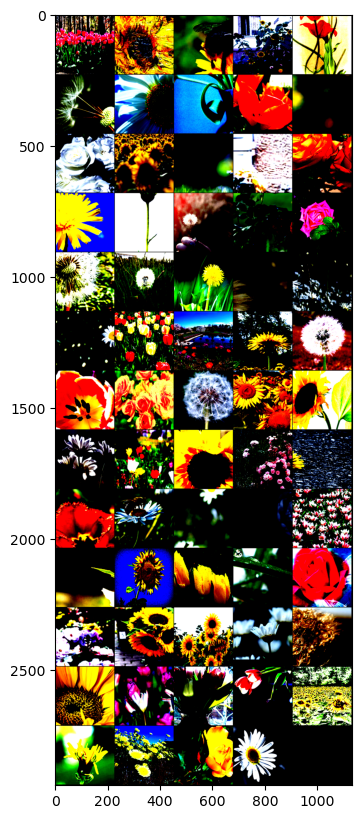

In [46]:
plt.figure(figsize=(10,10))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

plt.show()

In [47]:
# Inverse Normalization.
inv_normalize=transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225],
                                     std=[1/0.229,1/0.224,1/0.225])
im=inv_normalize(im)

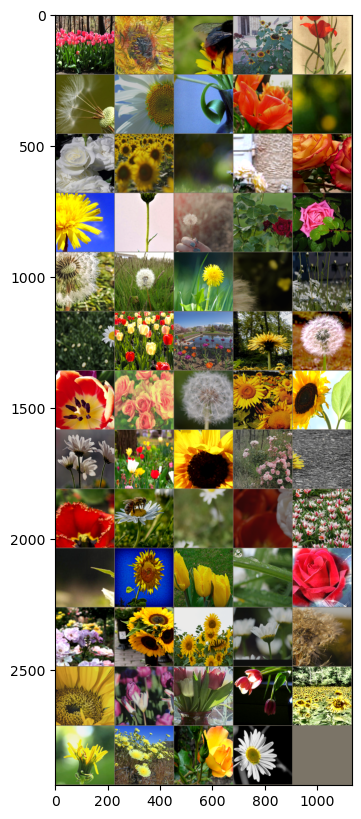

In [48]:
plt.figure(figsize=(10,10))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

plt.show()

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class TransferLearningModel(nn.Module):
    def __init__(self, classes):
        super().__init__()

        weights = EfficientNet_B0_Weights.DEFAULT
        self.model = efficientnet_b0(weights=weights)

        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, classes)

    def forward(self, x):
        return self.model(x)


LEARNING_RATE = 0.001

num_classes = 5

model = to_device(TransferLearningModel(num_classes), device)


train_loader = DeviceDataLoader(train_loader, device)
test_loader = DeviceDataLoader(test_loader, device)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [126]:
model

TransferLearningModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              

In [127]:
# Counting of number of parameters in the model.
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>8}')
    print(f'________\n{sum(params):>8}')

count_parameters(model)

     864
      32
      32
     288
      32
      32
     256
       8
     256
      32
     512
      16
      16
    1536
      96
      96
     864
      96
      96
     384
       4
     384
      96
    2304
      24
      24
    3456
     144
     144
    1296
     144
     144
     864
       6
     864
     144
    3456
      24
      24
    3456
     144
     144
    3600
     144
     144
     864
       6
     864
     144
    5760
      40
      40
    9600
     240
     240
    6000
     240
     240
    2400
      10
    2400
     240
    9600
      40
      40
    9600
     240
     240
    2160
     240
     240
    2400
      10
    2400
     240
   19200
      80
      80
   38400
     480
     480
    4320
     480
     480
    9600
      20
    9600
     480
   38400
      80
      80
   38400
     480
     480
    4320
     480
     480
    9600
      20
    9600
     480
   38400
      80
      80
   38400
     480
     480
   12000
     480
     480
    9600
 

In [ ]:
# Learning Schema.
import time
start_time=time.time()
train_losses=[]
test_losses=[]
train_correct=[]
test_correct=[]
epochs=5

for i in range(epochs):
    trn_corr=0
    tst_corr=0
    for b, (X_train,y_train) in enumerate(train_loader):
        b+=1
        # print(X_train.device,y_train.device)
        y_pred=model(X_train)
        # print(y_pred.device)
        loss=criterion(y_pred,y_train)

        predicted=torch.max(y_pred.data,1)[1]
        batch_corr=(predicted==y_train).sum()
        trn_corr+=batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Note that this line only gives training accuracy
        if b%10==0:
            print(f"epoch: {i} loss: {loss.item()} batch: {b} accuracy: {trn_corr.item()*100/(10*b):7.3f}%")
    loss=loss.detach()
    train_losses.append(loss.cpu().numpy())
    train_correct.append(trn_corr.cpu().numpy())


    with torch.no_grad():
        for b, (X_test,y_test) in enumerate(test_loader):
            y_val=model(X_test)
            loss=criterion(y_val,y_test)

            predicted=torch.max(y_val.data,1)[1]
            btach_corr=(predicted==y_test).sum()
            tst_corr+=btach_corr

        loss=loss.detach().cpu().numpy()
        test_losses.append(loss)
        test_correct.append(tst_corr.cpu().numpy())
    print(f'epoch: {i}, test accuracy: {tst_corr*100/len(test_data):7.3f}%')

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

epoch: 0 loss: 0.7504527568817139 batch: 10 accuracy: 452.000%
epoch: 0 loss: 0.7268800735473633 batch: 20 accuracy: 493.500%
epoch: 0 loss: 0.7342614531517029 batch: 30 accuracy: 503.667%
epoch: 0 loss: 0.6718704700469971 batch: 40 accuracy: 511.500%
epoch: 0 loss: 0.6261208653450012 batch: 50 accuracy: 521.200%
epoch: 0, test accuracy:  86.806%
epoch: 1 loss: 0.6538276672363281 batch: 10 accuracy: 562.000%
epoch: 1 loss: 0.5827730894088745 batch: 20 accuracy: 568.500%
epoch: 1 loss: 0.5673778057098389 batch: 30 accuracy: 570.000%
epoch: 1 loss: 0.6440584659576416 batch: 40 accuracy: 566.750%
epoch: 1 loss: 0.5727642178535461 batch: 50 accuracy: 570.000%
epoch: 1, test accuracy:  88.310%
epoch: 2 loss: 0.48762428760528564 batch: 10 accuracy: 594.000%
epoch: 2 loss: 0.6758631467819214 batch: 20 accuracy: 592.500%
epoch: 2 loss: 0.523586630821228 batch: 30 accuracy: 590.000%
epoch: 2 loss: 0.6108452081680298 batch: 40 accuracy: 586.000%
epoch: 2 loss: 0.6475273370742798 batch: 50 accura

I chose 15 epochs when testing my model as in the output above. After running it, I changed the code back to 5 epochs as it was originally set.

[array(0.7464453, dtype=float32), array(0.56420267, dtype=float32), array(0.65076387, dtype=float32), array(0.5409676, dtype=float32), array(0.44141957, dtype=float32), array(0.48667797, dtype=float32), array(0.5856039, dtype=float32), array(0.60680425, dtype=float32), array(0.5881197, dtype=float32), array(0.5229953, dtype=float32), array(0.4561638, dtype=float32), array(0.46493256, dtype=float32), array(0.49477714, dtype=float32), array(0.480233, dtype=float32), array(0.4853226, dtype=float32)]


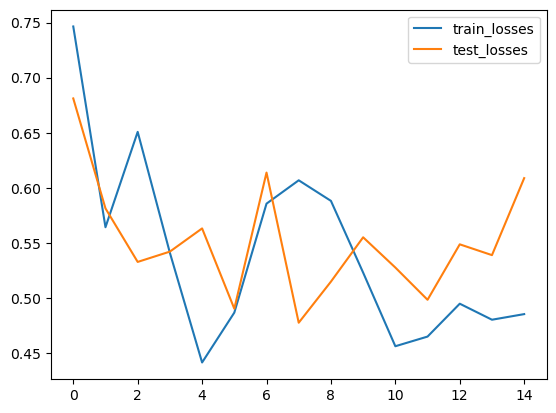

In [130]:
# Plotting loss over time.
plt.plot(train_losses,label="train_losses")
plt.plot(test_losses,label="test_losses")
plt.legend()
print(train_losses)

plt.show()

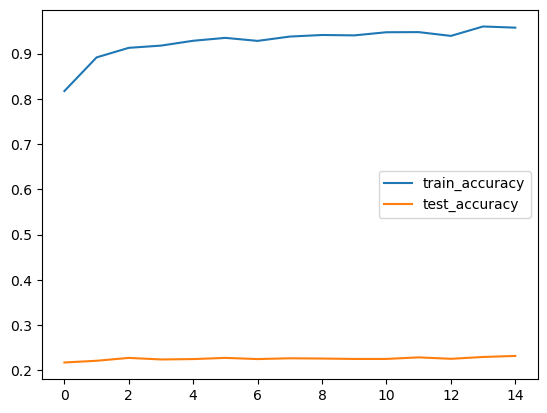

In [131]:
plt.plot(np.array(train_correct)/len(train_data),label="train_accuracy")
plt.plot(np.array(test_correct)/len(train_data),label="test_accuracy")
plt.legend()

plt.show()

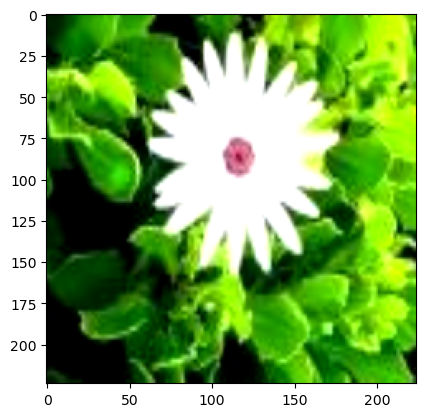

In [132]:
x=100
im = inv_normalize(test_data[x][0])
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

plt.show()

In [133]:
test_data[x][0].shape
test_data[x][0].device

device(type='cpu')

In [134]:
# Prediction for one of the samples.
model.eval()
with torch.no_grad():
    new_pred=model(to_device(test_data[x][0].view(1,3,224,224),device)).argmax()
print(f'Predicted value: {new_pred.item()} {class_names[new_pred.item()]}')

Predicted value: 0 daisy


##FLOPs
In deep learning, FLOPs (Floating Point Operations) quantify the total number of arithmetic operations—such as additions, multiplications, and divisions—that a model performs during a single forward pass (i.e., when making a prediction). This metric serves as an indicator of a model’s computational complexity. When discussing large-scale models, FLOPs are often expressed in GFLOPs (Giga Floating Point Operations), where 1 GFLOP equals one billion operations. This unit helps in comparing the computational demands of different models.

In [90]:
# we use fvcore to calculate the FLOPs
!pip install fvcore

In [15]:
from fvcore.nn import FlopCountAnalysis
input = torch.randn(1, 3, 224, 224) # The input size should be the same as the size that you put into your model
#Get the network and its FLOPs
num_classes = 5
model = TransferLearningModel(num_classes)
flops = FlopCountAnalysis(model, input)
print(f"FLOPs: {flops.total()/1e9:.5f} GFLOPs")

Unsupported operator aten::add_ encountered 58 time(s)
Unsupported operator aten::silu_ encountered 49 time(s)
Unsupported operator aten::sigmoid encountered 16 time(s)
Unsupported operator aten::mul encountered 25 time(s)
Unsupported operator aten::bernoulli_ encountered 9 time(s)
Unsupported operator aten::div_ encountered 9 time(s)
Unsupported operator aten::dropout_ encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
model.features.1.0.stochastic_depth, model.features.2.0.stochastic_depth, model.features.3.0.stochastic_depth, model.features.4.0.stochastic_depth, model.features.5.0.stochastic_depth, model.features.6.0.stochastic_depth, model.features.7.0.stochastic_depth


FLOPs: 0.42060 GFLOPs
